In [124]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score

In [125]:
def get_dominant_region_mode_year(
    ds_dict,
    region,
    mode,
    landtypes,
    year
):

    time = f"{year}-01-01"
    stacks = []

    for lt in landtypes:
        ds = ds_dict[mode][lt]
        varname = f"{region}_{mode}_{lt}"
        da = ds[varname].sel(time=time)
        stacks.append(da)

    data = xr.concat(stacks, dim="class")
    data_filled = data.fillna(0)

    dominant = data_filled.argmax(dim="class")

    # 若该格点三类均为 0（即不属于该 region），设为 NaN
    mask = data_filled.sum(dim="class") == 0
    dominant = dominant.where(~mask)

    return dominant

In [126]:
def calc_kappa_region_year(
    ds_dict,
    region,
    landtypes,
    year
):
    dom_region = get_dominant_region_mode_year(
        ds_dict, region, "region", landtypes, year
    )
    dom_basin = get_dominant_region_mode_year(
        ds_dict, region, "basin", landtypes, year
    )

    a = dom_region.values.flatten()
    b = dom_basin.values.flatten()

    mask = np.isfinite(a) & np.isfinite(b)

    kappa = cohen_kappa_score(
        a[mask].astype(int),
        b[mask].astype(int)
    )

    return round(kappa, 3)


In [127]:
def calc_kappa_region_timeseries(
    ds_dict,
    region,
    landtypes,
    years
):
    return [
        calc_kappa_region_year(ds_dict, region, landtypes, y)
        for y in years
    ]


In [128]:
def load_landuse_nc(base_path="../../NC"):
    ds_dict = {
        "region": {
            "agri":      xr.open_dataset(f"{base_path}/region_agri_17regions.nc"),
            "forest":    xr.open_dataset(f"{base_path}/region_forest_17regions.nc"),
            "grassland": xr.open_dataset(f"{base_path}/region_grassland_17regions.nc"),
        },
        "basin": {
            "agri":      xr.open_dataset(f"{base_path}/basin_agri_17regions.nc"),
            "forest":    xr.open_dataset(f"{base_path}/basin_forest_17regions.nc"),
            "grassland": xr.open_dataset(f"{base_path}/basin_grassland_17regions.nc"),
        }
    }
    return ds_dict




In [129]:
def calc_all_regions_kappa_timeseries(
    ds_dict,
    regions,
    landtypes,
    years
):
    results = {}

    for reg in regions:
        print(f"Processing {reg}")
        results[reg] = calc_kappa_region_timeseries(
            ds_dict,
            reg,
            landtypes,
            years
        )

    return results


In [130]:
kappa_global = [
    0.823, 0.818, 0.808, 0.815, 0.813,
    0.806, 0.791, 0.780, 0.767, 0.758, 0.750
]

In [131]:
def plot_kappa_18_panels(years,region_kappa,kappa_global,regions):
    plt.style.use("default")
    regions= regions + ["WLD"]
    n = len(regions)

    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(16, 12),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    # -------- region panels --------
    for i, reg in enumerate(regions):
        ax = axes[i]
        if reg == "WLD":
            ax.plot(
                years,
                kappa_global,
                #marker="o",
                linewidth=1.8,
            )
        else:
            ax.plot(
                years,
                region_kappa[reg],
                #marker="o",
                linewidth=1.8
            )
        ax.set_title(reg, fontsize=13)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        if i >= n - 5:
            ax.tick_params(axis="x", labelbottom=True)
            ax.set_xlabel("Year",fontsize=13)
        else:
            ax.tick_params(axis="x", labelbottom=False)

    # -------- axis labels --------


    for ax in axes[::ncols]:
        ax.set_ylabel("Kappa")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("../../plot/kappa/kappa_region_vs_basin.png")
    plt.show()


Processing BRA
Processing CAN
Processing CHN
Processing CIS
Processing IND
Processing JPN
Processing TUR
Processing USA
Processing XAF
Processing XE25
Processing XER
Processing XLM
Processing XME
Processing XNF
Processing XOC
Processing XSA
Processing XSE


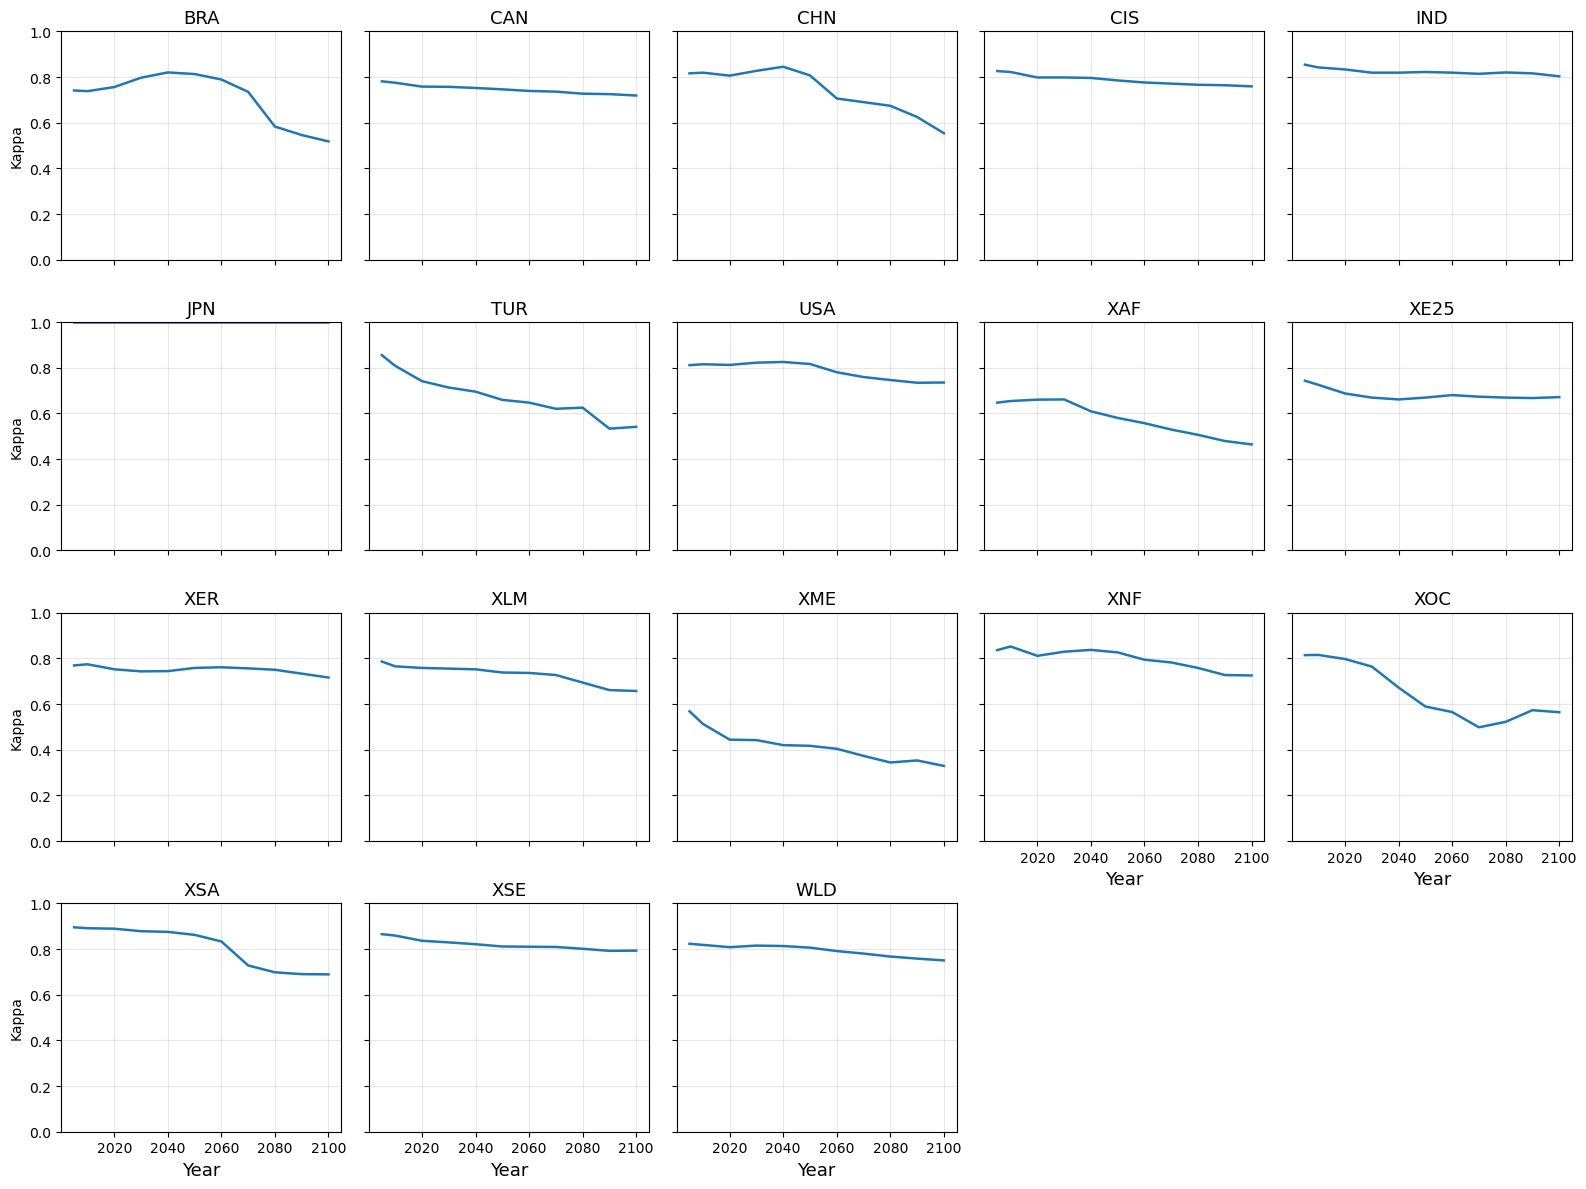

In [132]:
regions = [
    "JPN","USA","CHN","IND","BRA","CAN","CIS",
    "XAF","XME","XNF","XSA","XSE","XOC",
    "XLM","XE25","XER","TUR"
]
regions = sorted(regions)

years = [2005] + list(range(2010, 2101, 10))
landtypes = ["agri", "forest", "grassland"]

kappa_global = [
    0.823, 0.818, 0.808, 0.815, 0.813,
    0.806, 0.791, 0.780, 0.767, 0.758, 0.750
]
ds_dict = load_landuse_nc("../../NC")

region_kappa = calc_all_regions_kappa_timeseries(
    ds_dict,
    regions,
    landtypes,
    years
)

plot_kappa_18_panels(
    years,
    region_kappa,
    kappa_global,
    regions
)
